In [1]:
from helper_functions import Discriminator, QuantumBronMachine, RBF_kernel, MMD_probs, all_bitstrings, sample_bitstrings_gumbel
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn 

In [2]:
device = "cpu"

In [3]:
n_qubits = 3
N = 2**n_qubits
M = 256
bits = all_bitstrings(n_qubits=n_qubits)

In [4]:
target_probs = torch.tensor([0.1, 0.2, 0.2, 0.05, 0.15, 0.1, 0.1, 0.1], dtype=torch.float32).to(device)
p_sampled = sample_bitstrings_gumbel(q_or_logits=target_probs,n_qubits=n_qubits, M=M).to(device)


K = RBF_kernel(target_probs, sigmas=torch.tensor([1.0]).to(device))

In [5]:
gen = QuantumBronMachine(n_qubits=n_qubits, n_layers=2).to(device)
disc = Discriminator(n_qubits=n_qubits, d_hidden= (24,24), dropout=0.0).to(device)

In [6]:
gen_opt = torch.optim.Adam(gen.parameters(), lr=0.0001)
disc_opt = torch.optim.Adam(disc.parameters(), lr=0.0005)

loss_fn = nn.BCEWithLogitsLoss()


In [7]:
def train_loop(model):
    gen_opt.zero_grad()
    disc_opt.zero_grad()

    q = torch.as_tensor(gen(),dtype=torch.float32) 
    
    q_sampled = sample_bitstrings_gumbel(q_or_logits=q, n_qubits=n_qubits, M=M).to(dtype=torch.float32)

    q_logits = disc(q_sampled)
    p_logits = disc(p_sampled)

    gen_loss = loss_fn(q_logits, torch.ones_like(q_logits))
    disc_loss = loss_fn(q_logits, torch.zeros_like(q_logits)) + loss_fn(p_logits, torch.ones_like(p_logits))

    if model == "GEN":
        gen_loss.backward()
        gen_opt.step()

    elif model == "DISC":
        disc_loss.backward()
        disc_opt.step()
    
    return q, q_sampled, gen_loss.item(), disc_loss.item()
    

# DISC Training

In [8]:
gen_loss_list = []
disc_loss_list = []

for hyper_epoch in range(6):
    for epoch in range(200):
        q, q_sampled, gen_loss, disc_loss = train_loop("DISC")
        gen_loss_list.append(gen_loss)
        disc_loss_list.append(disc_loss)
    for epoch in range(300):
        q, q_sampled, gen_loss, disc_loss = train_loop("GEN")
        gen_loss_list.append(gen_loss)
        disc_loss_list.append(disc_loss)

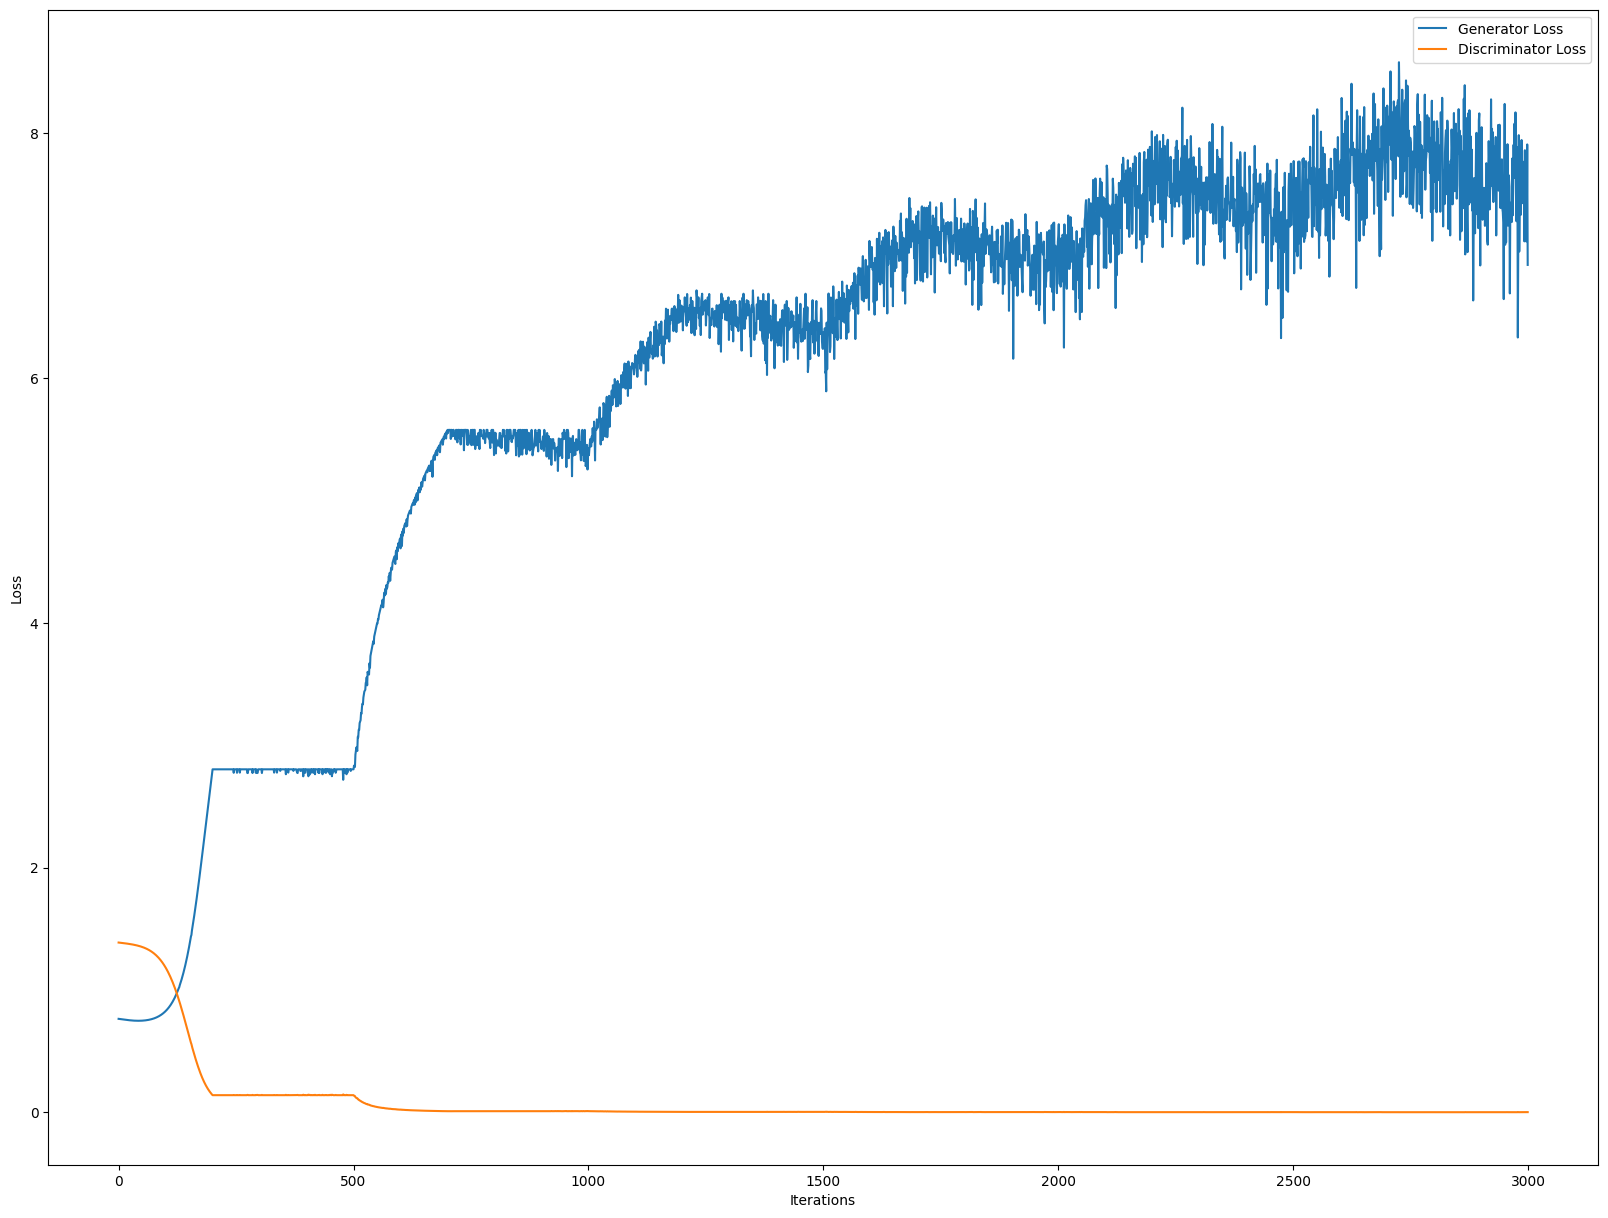

In [9]:
plt.figure(figsize=(20,15))
plt.plot(gen_loss_list, label="Generator Loss")
plt.plot(disc_loss_list, label="Discriminator Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [10]:
test = gen()
print(test)

tensor([9.1050e-01, 3.3545e-04, 2.1156e-02, 1.0444e-02, 1.1135e-02, 1.5301e-02,
        1.4235e-02, 1.6892e-02], dtype=torch.float64,
       grad_fn=<ExecuteTapesBackward>)
